# 1. Global Earthquakes

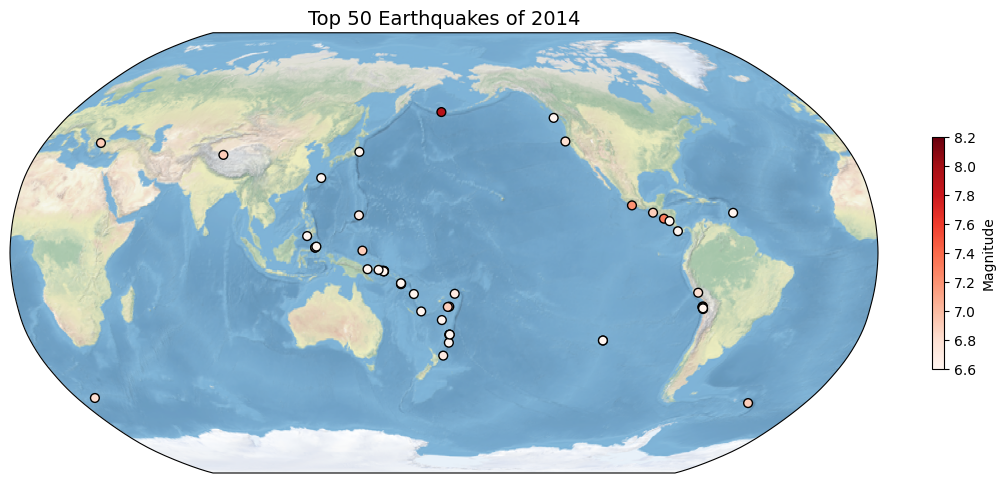

In [77]:
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ========================
# 1. 读取地震数据
# ========================
df = pd.read_csv("usgs_earthquakes.csv")
df_top50 = df.sort_values(by="mag", ascending=False).head(50)

lat = df_top50["latitude"]
lon = df_top50["longitude"]
mag = df_top50["mag"]

# ========================
# 2. Robinson 投影 + 180° 中心经度
# ========================
plt.figure(figsize=(14, 7))
ax = plt.axes(projection=ccrs.Robinson(central_longitude=180))
ax.set_global()

# ========================
#  添加真实卫星底图（Blue Marble）
# ========================
ax.stock_img()

# ========================
# 3. 绘制 Top 50 地震散点
# ========================
scatter = ax.scatter(
    lon,
    lat,
    c=mag,
    cmap="Reds",              # 白 → 红
    s=40,
    transform=ccrs.PlateCarree(),
    edgecolor="black",
    linewidth=1
)

# ========================
# 4. 右侧竖直 colorbar
# ========================
scatter.set_clim(6.6, 8.2)

cbar = plt.colorbar(
    scatter,
    orientation="vertical",   # ← 竖直 colorbar
    pad=0.05,                 # ← 调整右侧距离
    shrink=0.43              # ← bar 高度缩放
)
cbar.set_label("Magnitude")

plt.title("Top 50 Earthquakes of 2014", fontsize=14)
# plt.show()
plt.savefig("4-1.jpg",dpi=600)

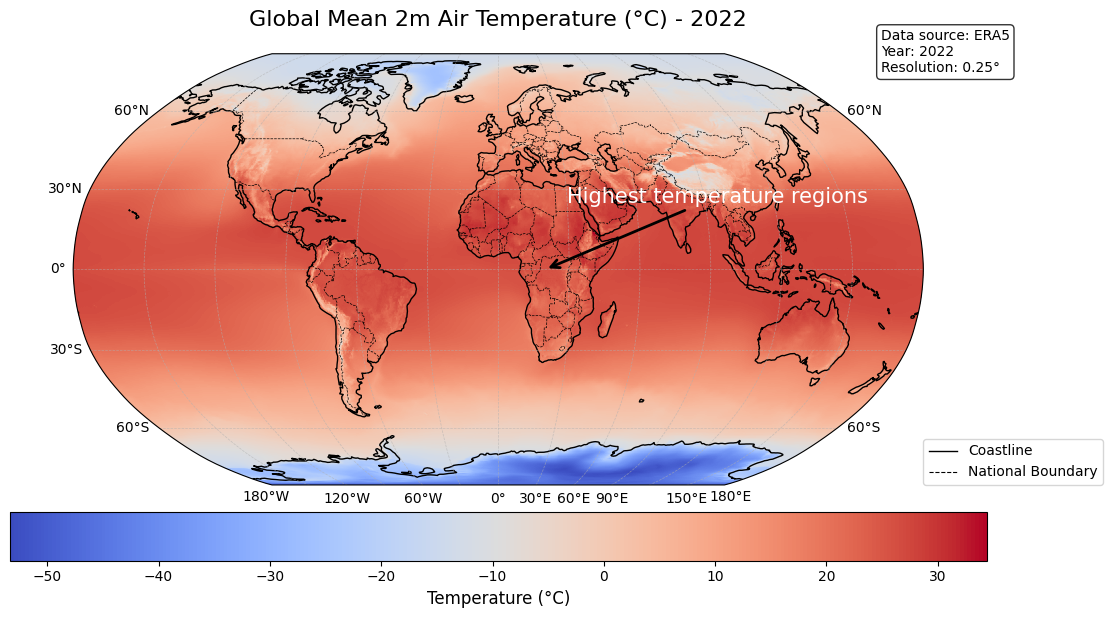

In [90]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import warnings
from cartopy.io.shapereader import natural_earth
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

warnings.simplefilter("ignore")  # 忽略 DownloadWarning

# ==============================
# 1. 打开 netCDF 数据
# ==============================
# 打开数据
ds = xr.open_dataset("ERA5_monthly_t2m_2022.nc")
# 取变量
t2m = ds['t2m']   # (time, lat, lon)
# 计算 2022年年平均
t2m_mean = t2m.mean(dim='valid_time')
# 单位转换：K → °C
t2m_mean = t2m_mean - 273.15
# 提取经纬度
lons = ds['longitude']
lats = ds['latitude']


# ==============================
# 2. 绘制全球图
# ==============================
fig = plt.figure(figsize=(14, 7))

# 2.0 project
ax = plt.axes(projection=ccrs.Robinson())
ax.set_global()

# 2.1 features
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='white')
ax.add_feature(cfeature.COASTLINE, linewidth=1)
ax.add_feature(cfeature.BORDERS, linestyle='--', linewidth=0.5)

# 绘图
im = ax.pcolormesh(
    lons, lats, t2m_mean,
    transform=ccrs.PlateCarree(),
    cmap='coolwarm'
)

# 2.2 gridlines
gl = ax.gridlines(draw_labels=True, linewidth=0.5, linestyle='--', alpha=0.6)
gl.top_labels = False
gl.right_labels = False
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
gl.xlabel_style = {'size': 10}
gl.ylabel_style = {'size': 10}

# 2.3-2.6
# x label and ticks
# y label and ticks
ax.set_xlabel("Longitude", fontsize=12)
ax.set_ylabel("Latitude", fontsize=12)

# 2.7 title
ax.set_title("Global Mean 2m Air Temperature (°C) - 2022", fontsize=16, pad=20)

# 2.8 Colorbar
cbar = plt.colorbar(im, orientation='horizontal', pad=0.05, shrink=0.9)
cbar.set_label("Temperature (°C)", fontsize=12)

# 2.9 legend
from matplotlib.lines import Line2D
coastline_proxy = Line2D(
    [0], [0],
    color='black',
    linewidth=1,
    label='Coastline'
)
border_proxy = Line2D(
    [0], [0],
    color='black',
    linestyle='--',
    linewidth=0.8,
    label='National Boundary'
)
plt.legend(
    handles=[coastline_proxy, border_proxy],
    loc='lower left',
    bbox_to_anchor=(1.0, 0.0),   # 放在图外右下角
    frameon=True,
    borderaxespad=0
)


# 2.10 Annotation
ax.annotate(
    'Highest temperature regions',color='white',
    xy=(20, 0), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax),
    xytext=(30, 25), textcoords=ccrs.PlateCarree()._as_mpl_transform(ax),
    arrowprops=dict(arrowstyle="->", linewidth=2),
    fontsize=15
)

# 2.11 Text box
ax.text(
    0.95, 0.95,
    "Data source: ERA5\nYear: 2022\nResolution: 0.25°",
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment='bottom',
    bbox=dict(facecolor='white', alpha=0.8, boxstyle='round')
)
# plt.show()
plt.savefig("4-2.jpg",dpi=600)


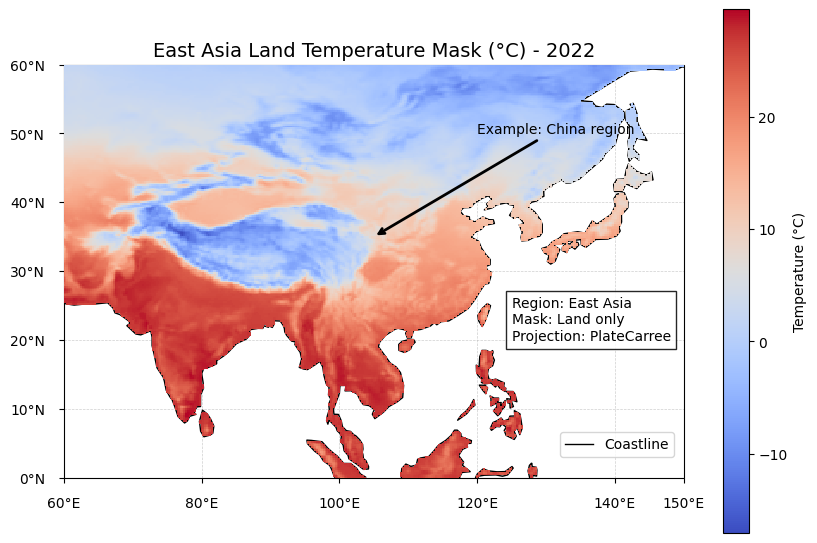

In [89]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.patches as mpatches
import numpy as np
from cartopy.io import shapereader
from shapely.vectorized import contains
import matplotlib.ticker as mticker

# ==============================
# 打开数据
# ==============================
ds = xr.open_dataset("ERA5_monthly_t2m_2022.nc")
t2m_mean = ds['t2m'].mean(dim='valid_time') - 273.15  # 转 °C

# ==============================
# 区域范围：East Asia
# ==============================
lon_min, lon_max = 60, 150
lat_min, lat_max = 0, 60

t2m_reg = t2m_mean.sel(
    longitude=slice(lon_min, lon_max),
    latitude=slice(lat_max, lat_min)
)

# ==============================
# 绘图
# ==============================
fig = plt.figure(figsize=(10, 8))

# 3.1 project：改为 PlateCarree
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

# ==============================
# 3.2 Mask: 先画海洋，再画陆地
# ==============================
ax.add_feature(cfeature.OCEAN, facecolor='white', zorder=1)
ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=2)
ax.add_feature(cfeature.COASTLINE, linewidth=1, zorder=3)
ax.add_feature(cfeature.RIVERS, linewidth=0.5, zorder=3)

# ==============================
# 绘制温度，仅在陆地上显示
# ==============================
land_shp = list(shapereader.Reader(shapereader.natural_earth(
    resolution='110m', category='physical', name='land')).geometries())

mask = np.zeros_like(t2m_reg, dtype=bool)
lon2d, lat2d = np.meshgrid(t2m_reg.longitude, t2m_reg.latitude)
points = np.array([lon2d.ravel(), lat2d.ravel()]).T

for geom in land_shp:
    mask_flat = contains(geom, points[:,0], points[:,1])
    mask |= mask_flat.reshape(lon2d.shape)

t2m_masked = np.where(mask, t2m_reg, np.nan)

im = ax.pcolormesh(
    t2m_reg.longitude,
    t2m_reg.latitude,
    t2m_masked,
    cmap='coolwarm',
    transform=ccrs.PlateCarree(),
    zorder=4
)

# ==============================
# 3.3 gridlines
# ==============================
gl = ax.gridlines(draw_labels=False, linewidth=0.5, linestyle='--', alpha=0.6)

# ==============================
# 3.4-3.7 自定义经纬度刻度在外部
# ==============================
ax.set_xticks([60, 80, 100, 120, 140, 150], crs=ccrs.PlateCarree())
ax.set_yticks([0, 10, 20, 30, 40, 50, 60], crs=ccrs.PlateCarree())
ax.tick_params(axis='x', which='both', direction='out', pad=10)
ax.tick_params(axis='y', which='both', direction='out', pad=10)
ax.xaxis.set_major_formatter(mticker.FixedFormatter(['60°E','80°E','100°E','120°E','140°E','150°E']))
ax.yaxis.set_major_formatter(mticker.FixedFormatter(['0°N','10°N','20°N','30°N','40°N','50°N','60°N']))

# ==============================
# 3.8-3.9 title和 colorbar
# ==============================
ax.set_title("East Asia Land Temperature Mask (°C) - 2022", fontsize=14)
cbar = plt.colorbar(im, orientation='vertical', shrink=0.85, pad=0.05)
cbar.set_label("Temperature (°C)")

# ==============================
# 3.10-3.11 注释和文本框
# ==============================
ax.annotate(
    'Example: China region',
    xy=(105, 35), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax),
    xytext=(120, 50), textcoords=ccrs.PlateCarree()._as_mpl_transform(ax),
    arrowprops=dict(arrowstyle="->", linewidth=2),
    fontsize=10,zorder=5
)

plt.text(
    125, 20,
    "Region: East Asia\nMask: Land only\nProjection: PlateCarree",
    transform=ccrs.PlateCarree(),
    fontsize=10,
    bbox=dict(facecolor='white', alpha=0.85),zorder=5
)

# ==============================
# 3.12 legend
# ==============================
from matplotlib.lines import Line2D
coastline_proxy = Line2D(
    [0], [0],
    color='black',
    linewidth=1,
    label='Coastline',zorder=1
)

plt.legend(
    handles=[coastline_proxy],
    loc='lower left',
    bbox_to_anchor=(0.8, 0.05),
    frameon=True,
    borderaxespad=0
)

plt.savefig("East_Asia_LandMask.jpg", dpi=600)
plt.show()
